<a href="https://colab.research.google.com/github/OrastaRakhmatullayeva/ML-projects/blob/main/Bagging_and_Boosting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split,GridSearchCV,cross_val_score
# from sklearn.ensemble import RandomForest

In [7]:
df = pd.read_csv("https://raw.githubusercontent.com/sinanuozdemir/sfdat22/master/data/bank.csv", sep=';')
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


In [8]:
df.shape

(4119, 21)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   object 
 2   marital         4119 non-null   object 
 3   education       4119 non-null   object 
 4   default         4119 non-null   object 
 5   housing         4119 non-null   object 
 6   loan            4119 non-null   object 
 7   contact         4119 non-null   object 
 8   month           4119 non-null   object 
 9   day_of_week     4119 non-null   object 
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   object 
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.conf.idx   4119 non-null   f

In [10]:
df.isnull().sum().sum()

np.int64(0)

In [13]:
df.duplicated().sum()

np.int64(0)

In [16]:
for col in df.select_dtypes(include='object').columns:
    print(col, df[col].unique())

job ['blue-collar' 'services' 'admin.' 'entrepreneur' 'self-employed'
 'technician' 'management' 'student' 'retired' 'housemaid' 'unemployed'
 'unknown']
marital ['married' 'single' 'divorced' 'unknown']
education ['basic.9y' 'high.school' 'university.degree' 'professional.course'
 'basic.6y' 'basic.4y' 'unknown' 'illiterate']
default ['no' 'unknown' 'yes']
housing ['yes' 'no' 'unknown']
loan ['no' 'unknown' 'yes']
contact ['cellular' 'telephone']
month ['may' 'jun' 'nov' 'sep' 'jul' 'aug' 'mar' 'oct' 'apr' 'dec']
day_of_week ['fri' 'wed' 'mon' 'thu' 'tue']
poutcome ['nonexistent' 'failure' 'success']
y ['no' 'yes']


In [14]:
df['y'].value_counts()

,count
y,
no,3668
yes,451


In [17]:
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()
df['y'] = le.fit_transform(df['y'])


In [18]:
X = df.drop(columns=['y'])
y = df['y']

X_encoded = pd.get_dummies(X, drop_first=True)

In [19]:
X_encoded.shape
X_encoded.head()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
0,30,487,2,999,0,-1.8,92.893,-46.2,1.313,5099.1,...,True,False,False,False,False,False,False,False,True,False
1,39,346,4,999,0,1.1,93.994,-36.4,4.855,5191.0,...,True,False,False,False,False,False,False,False,True,False
2,25,227,1,999,0,1.4,94.465,-41.8,4.962,5228.1,...,False,False,False,False,False,False,False,True,True,False
3,38,17,3,999,0,1.4,94.465,-41.8,4.959,5228.1,...,False,False,False,False,False,False,False,False,True,False
4,47,58,1,999,0,-0.1,93.200,-42.0,4.191,5195.8,...,False,True,False,False,True,False,False,False,True,False


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_proba_dt = dt.predict_proba(X_test)[:, 1]

print("Decision Tree:")
print(classification_report(y_test, y_pred_dt))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_dt))

Decision Tree:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94       734
           1       0.50      0.48      0.49        90

    accuracy                           0.89       824
   macro avg       0.72      0.71      0.71       824
weighted avg       0.89      0.89      0.89       824

ROC-AUC: 0.7095973357553739


Bagging va Boosting

In [21]:
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier

bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100,
    random_state=42
)
bagging.fit(X_train, y_train)
y_pred_bag = bagging.predict(X_test)
y_proba_bag = bagging.predict_proba(X_test)[:, 1]

print("Bagging:")
print(classification_report(y_test, y_pred_bag))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_bag))

adaboost = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
    n_estimators=100,
    random_state=42
)
adaboost.fit(X_train, y_train)
y_pred_ada = adaboost.predict(X_test)
y_proba_ada = adaboost.predict_proba(X_test)[:, 1]

print("AdaBoost:")
print(classification_report(y_test, y_pred_ada))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_ada))

gboost = GradientBoostingClassifier(random_state=42)
gboost.fit(X_train, y_train)
y_pred_gb = gboost.predict(X_test)
y_proba_gb = gboost.predict_proba(X_test)[:, 1]

print("Gradient Boosting:")
print(classification_report(y_test, y_pred_gb))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_gb))

Bagging:
              precision    recall  f1-score   support

           0       0.94      0.97      0.95       734
           1       0.65      0.50      0.57        90

    accuracy                           0.92       824
   macro avg       0.80      0.73      0.76       824
weighted avg       0.91      0.92      0.91       824

ROC-AUC: 0.9317438692098092
AdaBoost:
              precision    recall  f1-score   support

           0       0.93      0.98      0.95       734
           1       0.68      0.38      0.49        90

    accuracy                           0.91       824
   macro avg       0.80      0.68      0.72       824
weighted avg       0.90      0.91      0.90       824

ROC-AUC: 0.9400015137753558
Gradient Boosting:
              precision    recall  f1-score   support

           0       0.94      0.97      0.95       734
           1       0.64      0.48      0.55        90

    accuracy                           0.91       824
   macro avg       0.79      0.72 

**Bagging** - trains Decision Trees in parallel across different random subsamples, averaging results (reducing variance)

**AdaBoost** - very weak trees (max_depth=1, called "stump") are trained sequentially, with each paying more attention to the error of the previous one.

**Gradient Boosting** - Similar to AdaBoost, but optimizes the error using a &quot;gradient&quot;, typically yielding a stronger result

..


**RANDOM FOREST**


In [22]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("Random Forest:")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))

Random Forest:
              precision    recall  f1-score   support

           0       0.92      0.98      0.95       734
           1       0.66      0.32      0.43        90

    accuracy                           0.91       824
   macro avg       0.79      0.65      0.69       824
weighted avg       0.89      0.91      0.89       824

ROC-AUC: 0.9389494399031184


FINAL GRAPH TO ILLUSTRATE THE ALL MODEL'S RESULT

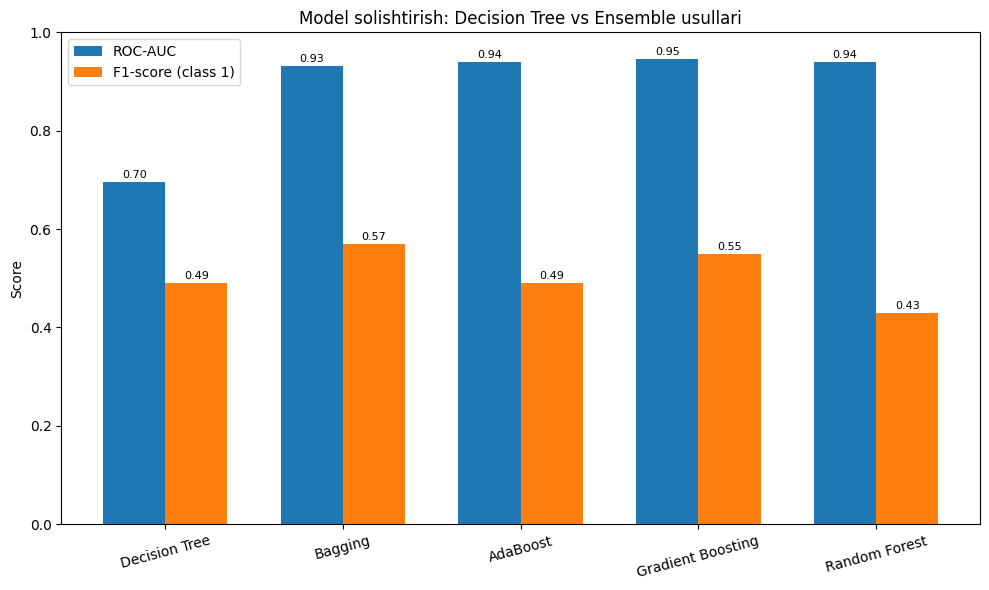

In [23]:
import matplotlib.pyplot as plt
import numpy as np

models = ['Decision Tree', 'Bagging', 'AdaBoost', 'Gradient Boosting', 'Random Forest']
roc_auc = [0.696, 0.932, 0.940, 0.946, 0.939]
f1_score_1 = [0.49, 0.57, 0.49, 0.55, 0.43]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, roc_auc, width, label='ROC-AUC')
bars2 = ax.bar(x + width/2, f1_score_1, width, label='F1-score (class 1)')

ax.set_ylabel('Score')
ax.set_title('Model solishtirish: Decision Tree vs Ensemble usullari')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15)
ax.set_ylim(0, 1)
ax.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', fontsize=8)

plt.tight_layout()
plt.show()

Final conclusion

*Bagging* is selected if recall is important to find as many potential yes customers as possible.

*Gradient Boosting* is selected if overall ranking quality (ROC-AUC) is important.